## Simulating the System

### Build the Barabási–Albert graph and Implement Kuramoto dynamics (RK4 integrator)

Nodes: 150, Edges: 441
Avg degree: 5.88


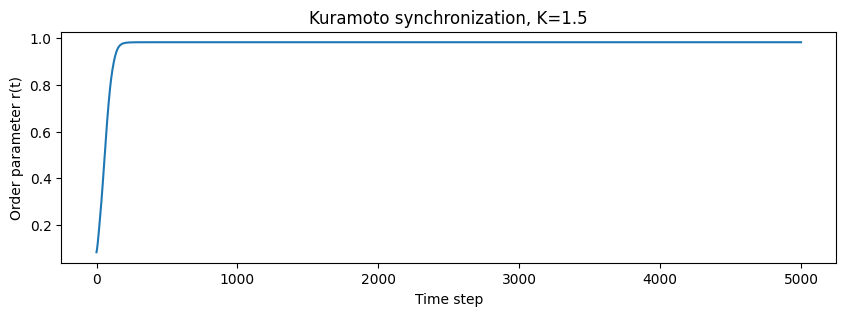

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# 1. Build the Barabási–Albert network
N = 150       # number of oscillators
m = 3         # edges per new node 
seed = 42

G = nx.barabasi_albert_graph(N, m, seed=seed)
A = nx.to_numpy_array(G)  # adjacency matrix, shape (N, N)

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
print(f"Avg degree: {2*G.number_of_edges()/N:.2f}")

#2. Kuramoto model dynamics
def kuramoto_rhs(theta, A, omega, K):
    """
    theta: (N,) current phases
    A: (N,N) adjacency matrix
    omega: (N,) natural frequencies
    K: coupling strength
    """
    # phase differences: theta_j - theta_i for all pairs
    diff = theta[np.newaxis, :] - theta[:, np.newaxis]  # (N,N)
    coupling = np.sum(A * np.sin(diff), axis=1)
    dtheta_dt = omega + K * coupling
    return dtheta_dt

def simulate_kuramoto(A, K, T=50, dt=0.01, omega=None, seed=0):
    """
    Runs Kuramoto dynamics on graph with adjacency A.
    Returns theta history (n_steps, N) and order parameter r(t).
    """
    rng = np.random.default_rng(seed)
    N = A.shape[0]

    if omega is None:
        omega = rng.normal(0, 1, N)  # natural frequencies, Lorentzian/normal spread

    theta = rng.uniform(0, 2*np.pi, N)  # random initial phases

    n_steps = int(T / dt)
    theta_history = np.zeros((n_steps, N))
    r_history = np.zeros(n_steps)

    for t in range(n_steps):
        # Runge-Kutta 4th order step (more stable than simple Euler)
        k1 = kuramoto_rhs(theta, A, omega, K)
        k2 = kuramoto_rhs(theta + dt/2*k1, A, omega, K)
        k3 = kuramoto_rhs(theta + dt/2*k2, A, omega, K)
        k4 = kuramoto_rhs(theta + dt*k3, A, omega, K)
        theta = theta + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)

        theta_history[t] = theta
        # order parameter: r*e^(i*psi) = (1/N) * sum(e^(i*theta_j))
        r_history[t] = np.abs(np.mean(np.exp(1j * theta)))

    return theta_history, r_history, omega

# 3. Quick test run
theta_hist, r_hist, omega = simulate_kuramoto(A, K=1.5, T=50, dt=0.01, seed=1)

plt.figure(figsize=(10, 3))
plt.plot(r_hist)
plt.xlabel("Time step")
plt.ylabel("Order parameter r(t)")
plt.title("Kuramoto synchronization, K=1.5")
plt.show()

### Scan K to locate critical coupling Kc

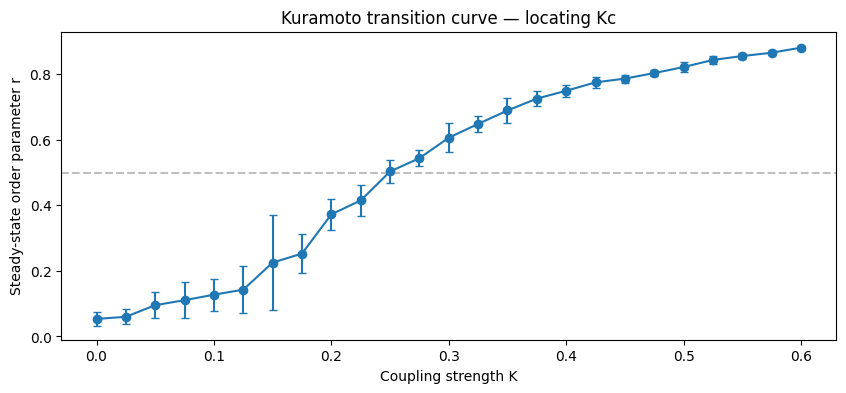

K=0.000  r_mean=0.054  r_std=0.021
K=0.025  r_mean=0.060  r_std=0.023
K=0.050  r_mean=0.095  r_std=0.039
K=0.075  r_mean=0.111  r_std=0.055
K=0.100  r_mean=0.127  r_std=0.049
K=0.125  r_mean=0.143  r_std=0.071
K=0.150  r_mean=0.226  r_std=0.145
K=0.175  r_mean=0.253  r_std=0.060
K=0.200  r_mean=0.373  r_std=0.048
K=0.225  r_mean=0.415  r_std=0.047
K=0.250  r_mean=0.503  r_std=0.034
K=0.275  r_mean=0.544  r_std=0.024
K=0.300  r_mean=0.606  r_std=0.044
K=0.325  r_mean=0.649  r_std=0.024
K=0.350  r_mean=0.690  r_std=0.038
K=0.375  r_mean=0.726  r_std=0.022
K=0.400  r_mean=0.750  r_std=0.018
K=0.425  r_mean=0.775  r_std=0.016
K=0.450  r_mean=0.787  r_std=0.012
K=0.475  r_mean=0.804  r_std=0.008
K=0.500  r_mean=0.822  r_std=0.014
K=0.525  r_mean=0.844  r_std=0.012
K=0.550  r_mean=0.856  r_std=0.009
K=0.575  r_mean=0.866  r_std=0.008
K=0.600  r_mean=0.881  r_std=0.006


In [2]:
#Step 1b: Scan K to locate the critical coupling Kc

K_values = np.linspace(0.0, 0.6, 25)  # fine scan in the low-K range
r_means = []
r_stds = []

for K in K_values:
    _, r_hist, _ = simulate_kuramoto(A, K=K, T=50, dt=0.01, seed=1)
    # use last 20% of the run (steady-state) to measure sync level
    steady = r_hist[int(0.8*len(r_hist)):]
    r_means.append(steady.mean())
    r_stds.append(steady.std())

r_means = np.array(r_means)
r_stds = np.array(r_stds)

#Plot the transition curve
plt.figure(figsize=(10, 4))
plt.errorbar(K_values, r_means, yerr=r_stds, fmt='o-', capsize=3)
plt.xlabel("Coupling strength K")
plt.ylabel("Steady-state order parameter r")
plt.title("Kuramoto transition curve — locating Kc")
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.show()

#Print table for exact values
for K, r_m, r_s in zip(K_values, r_means, r_stds):
    print(f"K={K:.3f}  r_mean={r_m:.3f}  r_std={r_s:.3f}")

#### So Kc is approximately 0.15–0.20 for this graph.


### Validate: run several seeds per regime, confirm r(t) traces look qualitatively distinct (flat-low / unstable-fluctuating / rises-and-plateaus)

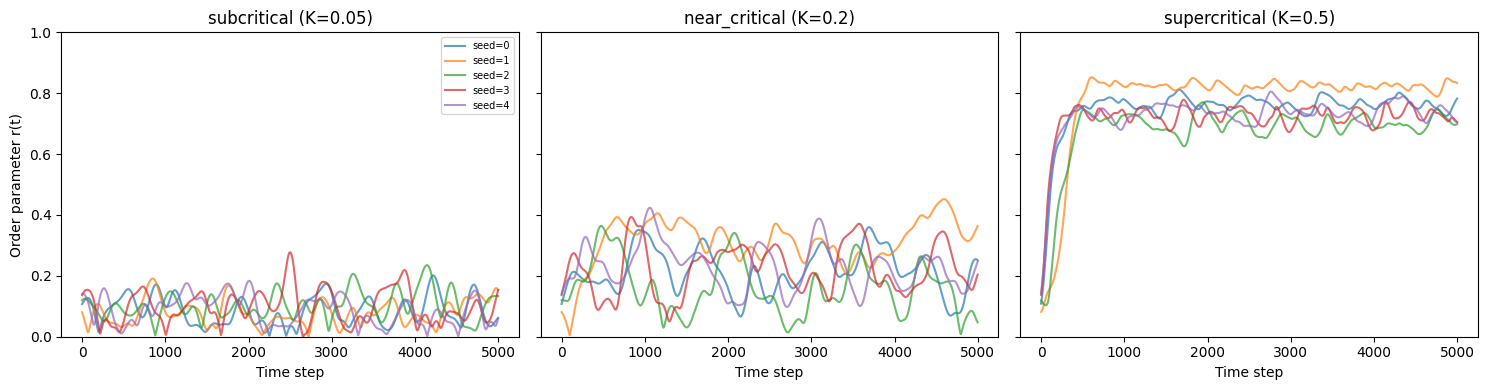


--- subcritical (K=0.05) ---
  seed=0  r_mean=0.098  r_std=0.053
  seed=1  r_mean=0.095  r_std=0.039
  seed=2  r_mean=0.117  r_std=0.064
  seed=3  r_mean=0.068  r_std=0.027
  seed=4  r_mean=0.063  r_std=0.038

--- near_critical (K=0.2) ---
  seed=0  r_mean=0.184  r_std=0.066
  seed=1  r_mean=0.373  r_std=0.048
  seed=2  r_mean=0.134  r_std=0.072
  seed=3  r_mean=0.213  r_std=0.069
  seed=4  r_mean=0.201  r_std=0.042

--- supercritical (K=0.5) ---
  seed=0  r_mean=0.764  r_std=0.019
  seed=1  r_mean=0.822  r_std=0.014
  seed=2  r_mean=0.699  r_std=0.020
  seed=3  r_mean=0.730  r_std=0.022
  seed=4  r_mean=0.751  r_std=0.025


In [3]:
# Step 1c: Validate the three chosen regimes across multiple seeds

regimes = {
    "subcritical": 0.05,
    "near_critical": 0.20,
    "supercritical": 0.50
}

n_seeds = 5
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (label, K) in zip(axes, regimes.items()):
    for seed in range(n_seeds):
        _, r_hist, _ = simulate_kuramoto(A, K=K, T=50, dt=0.01, seed=seed)
        ax.plot(r_hist, alpha=0.7, label=f"seed={seed}")
    ax.set_title(f"{label} (K={K})")
    ax.set_xlabel("Time step")
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Order parameter r(t)")
axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

# Print steady-state stats per regime, per seed
for label, K in regimes.items():
    print(f"\n--- {label} (K={K}) ---")
    for seed in range(n_seeds):
        _, r_hist, _ = simulate_kuramoto(A, K=K, T=50, dt=0.01, seed=seed)
        steady = r_hist[int(0.8*len(r_hist)):]
        print(f"  seed={seed}  r_mean={steady.mean():.3f}  r_std={steady.std():.3f}")

## Building the Labeled Dataset

### For each of the 3 regimes, run many simulations with different random seeds (varying initial phases and natural frequencies ω) to get diverse r(t) trajectories

In [4]:
regimes = {
    "subcritical": 0.05,
    "near_critical": 0.20,   
    "supercritical": 0.50
}

n_simulations_per_regime = 40
T = 50
dt = 0.01

raw_data = {label: [] for label in regimes}

for label, K in regimes.items():
    for seed in range(n_simulations_per_regime):
        _, r_hist, _ = simulate_kuramoto(A, K=K, T=T, dt=dt, seed=seed)
        raw_data[label].append(r_hist)
    print(f"{label} (K={K}): generated {len(raw_data[label])} trajectories")

subcritical (K=0.05): generated 40 trajectories
near_critical (K=0.2): generated 40 trajectories
supercritical (K=0.5): generated 40 trajectories


In [5]:
#Slice trajectories into windows (window=100, stride=50)

window_size = 100
stride = 50

X_list = []
y_list = []

label_to_int = {"subcritical": 0, "near_critical": 1, "supercritical": 2}

for label, trajectories in raw_data.items():
    class_idx = label_to_int[label]
    for r_hist in trajectories:
        n_steps = len(r_hist)
        for start in range(0, n_steps - window_size + 1, stride):
            window = r_hist[start:start + window_size]
            X_list.append(window)
            y_list.append(class_idx)

X = np.array(X_list)  # shape: (n_samples, window_size)
y = np.array(y_list)  # shape: (n_samples,)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class distribution: {np.bincount(y)}")
print(f"Label mapping: {label_to_int}")

X shape: (11880, 100)
y shape: (11880,)
Class distribution: [3960 3960 3960]
Label mapping: {'subcritical': 0, 'near_critical': 1, 'supercritical': 2}


In [6]:
#Rebuild X, y, groups, window_starts with new near-critical data

window_size = 100
stride = 50

X_list = []
y_list = []
groups_list = []
window_starts = []

label_to_int = {"subcritical": 0, "near_critical": 1, "supercritical": 2}

group_id = 0
for label, trajectories in raw_data.items():
    class_idx = label_to_int[label]
    for r_hist in trajectories:
        n_steps = len(r_hist)
        for start in range(0, n_steps - window_size + 1, stride):
            window = r_hist[start:start + window_size]
            X_list.append(window)
            y_list.append(class_idx)
            groups_list.append(group_id)
            window_starts.append(start)
        group_id += 1

X = np.array(X_list)
y = np.array(y_list)
groups = np.array(groups_list)
window_starts = np.array(window_starts)

print(f"X shape: {X.shape}, Class distribution: {np.bincount(y)}")

X shape: (11880, 100), Class distribution: [3960 3960 3960]


In [7]:
#Grouped train/val/test split

from sklearn.model_selection import GroupShuffleSplit

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss_test.split(X, y, groups=groups))

X_train_val, X_test = X[train_val_idx], X[test_idx]
y_train_val, y_test = y[train_val_idx], y[test_idx]
groups_train_val = groups[train_val_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss_val.split(X_train_val, y_train_val, groups=groups_train_val))

X_train, X_val = X_train_val[train_idx], X_train_val[val_idx]
y_train, y_val = y_train_val[train_idx], y_train_val[val_idx]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train class balance: {np.bincount(y_train)}")
print(f"Val class balance:   {np.bincount(y_val)}")
print(f"Test class balance:  {np.bincount(y_test)}")

# Sanity check for leakage
train_groups = set(groups_train_val[train_idx])
val_groups = set(groups_train_val[val_idx])
test_groups = set(groups[test_idx])
print(f"Overlaps (should all be empty): {train_groups & val_groups}, {train_groups & test_groups}, {val_groups & test_groups}")

Train: (7524, 100), Val: (1980, 100), Test: (2376, 100)
Train class balance: [2277 2673 2574]
Val class balance:   [891 297 792]
Test class balance:  [792 990 594]
Overlaps (should all be empty): set(), set(), set()


## Build and Train 1D-CNN

### Design a 3-layer 1D-CNN 

In [8]:
import torch
import torch.nn as nn

class KuramotoCNN(nn.Module):
    def __init__(self, window_size=100, n_classes=3):
        super().__init__()

        # Input shape: (batch, 1, window_size) -- 1 channel since r(t) is a single scalar signal
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(16)
        self.pool1 = nn.MaxPool1d(kernel_size=2)  # window_size -> window_size/2

        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(kernel_size=2)  # -> window_size/4

        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(64)
        self.pool3 = nn.MaxPool1d(kernel_size=2)  # -> window_size/8

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

        # Compute flattened size dynamically so window_size changes don't break this
        flattened_size = 64 * (window_size // 8)

        self.fc1 = nn.Linear(flattened_size, 64)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x):
        # x shape: (batch, 1, window_size)
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))

        x = x.flatten(start_dim=1)  # (batch, 64 * window_size//8)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)  # raw logits, softmax applied via loss function
        return x

# Quick sanity check: does a forward pass work with the right shapes?
model = KuramotoCNN(window_size=100, n_classes=3)
dummy_input = torch.randn(8, 1, 100)  # batch of 8, 1 channel, 100 timesteps
output = model(dummy_input)
print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")  # should be (8, 3)
print(model)

Input shape: torch.Size([8, 1, 100])
Output shape: torch.Size([8, 3])
KuramotoCNN(
  (conv1): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=768, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=3, bias=True)


In [16]:
#REVISED
class KuramotoCNN(nn.Module):
    def __init__(self, window_size=100, n_classes=3):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, padding=2, stride=2)
        self.bn1 = nn.BatchNorm1d(16)

        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, padding=2, stride=2)
        self.bn2 = nn.BatchNorm1d(32)

        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1, stride=2)
        self.bn3 = nn.BatchNorm1d(64)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

        # Compute flattened size dynamically via a dummy forward pass -- robust to any window_size
        with torch.no_grad():
            dummy = torch.zeros(1, 1, window_size)
            dummy_out = self._conv_forward(dummy)
            flattened_size = dummy_out.flatten(start_dim=1).shape[1]

        self.fc1 = nn.Linear(flattened_size, 64)
        self.fc2 = nn.Linear(64, n_classes)

    def _conv_forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.relu(self.bn3(self.conv3(x)))
        return x

    def forward(self, x):
        x = self._conv_forward(x)
        x = x.flatten(start_dim=1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Sanity check
model = KuramotoCNN(window_size=100, n_classes=3)
dummy_input = torch.randn(8, 1, 100)
output = model(dummy_input)
print(f"Output shape: {output.shape}")  # should be (8, 3)

Output shape: torch.Size([8, 3])


### Training Loop

In [17]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

# ---- Wrap data into PyTorch Datasets ----

class KuramotoDataset(Dataset):
    def __init__(self, X, y):
        # X shape: (n_samples, window_size) -> needs (n_samples, 1, window_size) for Conv1d
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = KuramotoDataset(X_train, y_train)
val_dataset = KuramotoDataset(X_val, y_val)
test_dataset = KuramotoDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

# ---- Setup ----

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = KuramotoCNN(window_size=100, n_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 100
patience = 10  # early stopping patience
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

# ---- Training loop ----

for epoch in range(n_epochs):
    # -- Train --
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total += y_batch.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # -- Validate --
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item() * X_batch.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:3d}/{n_epochs}  train_loss={train_loss:.4f} train_acc={train_acc:.4f}  val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    # -- Early stopping --
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# ---- Load best model ----
model.load_state_dict(best_model_state)
print(f"\nBest val_loss: {best_val_loss:.4f}")

Train batches: 236, Val batches: 62, Test batches: 75
Using device: cpu
Epoch   1/100  train_loss=0.2904 train_acc=0.8894  val_loss=0.2133 val_acc=0.9247
Epoch   2/100  train_loss=0.2369 train_acc=0.9135  val_loss=0.2157 val_acc=0.9263
Epoch   3/100  train_loss=0.2153 train_acc=0.9193  val_loss=0.1996 val_acc=0.9338
Epoch   4/100  train_loss=0.2247 train_acc=0.9164  val_loss=0.1835 val_acc=0.9379
Epoch   5/100  train_loss=0.2064 train_acc=0.9213  val_loss=0.2302 val_acc=0.9081
Epoch   6/100  train_loss=0.2007 train_acc=0.9269  val_loss=0.1778 val_acc=0.9374
Epoch   7/100  train_loss=0.1973 train_acc=0.9282  val_loss=0.1978 val_acc=0.9247
Epoch   8/100  train_loss=0.1925 train_acc=0.9256  val_loss=0.1992 val_acc=0.9369
Epoch   9/100  train_loss=0.1931 train_acc=0.9254  val_loss=0.1863 val_acc=0.9399
Epoch  10/100  train_loss=0.1941 train_acc=0.9277  val_loss=0.1916 val_acc=0.9354
Epoch  11/100  train_loss=0.2015 train_acc=0.9253  val_loss=0.1809 val_acc=0.9394
Epoch  12/100  train_loss=

Test accuracy: 0.7332

Classification report:
               precision    recall  f1-score   support

  subcritical       0.56      1.00      0.72       792
near_critical       0.98      0.37      0.54       990
supercritical       1.00      0.98      0.99       594

     accuracy                           0.73      2376
    macro avg       0.85      0.78      0.75      2376
 weighted avg       0.84      0.73      0.71      2376

Confusion matrix (rows=true, cols=predicted):
                    subcritical   near_critical   supercritical
    subcritical             792               0               0
  near_critical             625             365               0
  supercritical               2               7             585


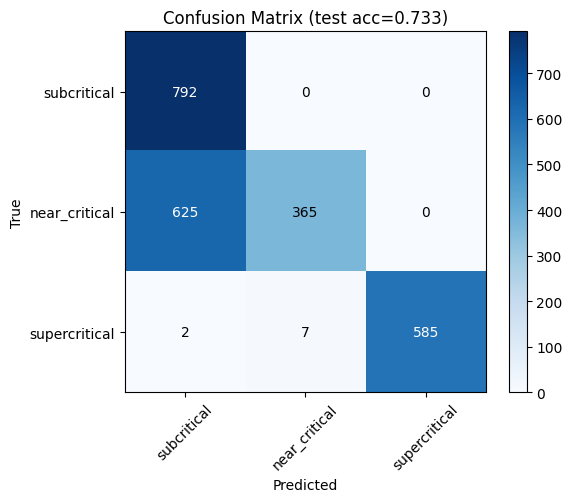

In [18]:
#Evaluate on test set + confusion matrix

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"Test accuracy: {test_acc:.4f}\n")

class_names = ["subcritical", "near_critical", "supercritical"]

print("Classification report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix (rows=true, cols=predicted):")
print(f"{'':>15}", *[f"{c:>15}" for c in class_names])
for i, row in enumerate(cm):
    print(f"{class_names[i]:>15}", *[f"{v:>15}" for v in row])

# Visualize
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(3), class_names, rotation=45)
plt.yticks(range(3), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix (test acc={test_acc:.3f})")
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.show()

## Interpretability

In [11]:
# Step 14 (lightweight version)

import shap
import torch
import numpy as np

model.eval()

def model_predict(x_numpy):
    x_tensor = torch.tensor(x_numpy, dtype=torch.float32).unsqueeze(1).to(device)
    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.softmax(logits, dim=1)
    return probs.cpu().numpy()

# Much smaller background: 10 representative points instead of 20
background_summary = shap.kmeans(X_train, 10)

explainer = shap.KernelExplainer(model_predict, background_summary)

class_names = ["subcritical", "near_critical", "supercritical"]
explain_size = 5  # down from 10 -- only 5 samples per class, 15 total

samples_to_explain = []
sample_labels = []

for class_idx in range(3):
    class_mask = (y_test == class_idx)
    class_indices = np.where(class_mask)[0]
    chosen = np.random.choice(class_indices, min(explain_size, len(class_indices)), replace=False)
    samples_to_explain.extend(chosen)
    sample_labels.extend([class_idx] * len(chosen))

X_explain = X_test[samples_to_explain]
sample_labels = np.array(sample_labels)

# nsamples down from 100 to 50 -- coarser approximation but much faster
shap_values = explainer.shap_values(X_explain, nsamples=50)

print(f"SHAP values computed for {X_explain.shape[0]} samples")
shap_arr = np.array(shap_values)
print(f"shap_arr shape: {shap_arr.shape}")

# Cache immediately so we never have to recompute this
np.save('shap_values_cache.npy', shap_arr)
np.save('sample_labels_cache.npy', sample_labels)
np.save('X_explain_cache.npy', X_explain)
print("Cached to disk.")

  0%|          | 0/15 [00:00<?, ?it/s]

c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 1 iterations, i.e. alpha=6.455e-02, with an active set of 1 regressors, and the smallest cholesky pivot element being 8.429e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 9 iterations, i.e. alpha=7.740e-03, with an active set of 9 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\shap\explainers\_kernel.py:765: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this si

SHAP values computed for 15 samples
shap_arr shape: (15, 100, 3)
Cached to disk.


In [19]:
#REVISED STEP 14
# Step 14 (GradientExplainer, now that MaxPool1d is gone)

import shap
import torch
import numpy as np

model.eval()

background_size = 100
explain_size = 30  # can afford more samples now that it's fast

background_idx = np.random.choice(len(X_train), background_size, replace=False)
background = torch.tensor(X_train[background_idx], dtype=torch.float32).unsqueeze(1).to(device)

explainer = shap.GradientExplainer(model, background)

class_names = ["subcritical", "near_critical", "supercritical"]
samples_to_explain = []
sample_labels = []

for class_idx in range(3):
    class_mask = (y_test == class_idx)
    class_indices = np.where(class_mask)[0]
    chosen = np.random.choice(class_indices, min(explain_size, len(class_indices)), replace=False)
    samples_to_explain.extend(chosen)
    sample_labels.extend([class_idx] * len(chosen))

sample_labels = np.array(sample_labels)
X_explain = torch.tensor(X_test[samples_to_explain], dtype=torch.float32).unsqueeze(1).to(device)

shap_values = explainer.shap_values(X_explain)

shap_arr = np.array(shap_values)
print(f"SHAP values computed for {X_explain.shape[0]} samples")
print(f"shap_arr shape: {shap_arr.shape}")

# Cache immediately
np.save('shap_values_cache.npy', shap_arr)
np.save('sample_labels_cache.npy', sample_labels)
np.save('X_explain_cache.npy', X_explain.cpu().numpy())
print("Cached to disk.")

SHAP values computed for 90 samples
shap_arr shape: (90, 1, 100, 3)
Cached to disk.


In [20]:
%matplotlib inline

shap_arr shape: (15, 100, 3)


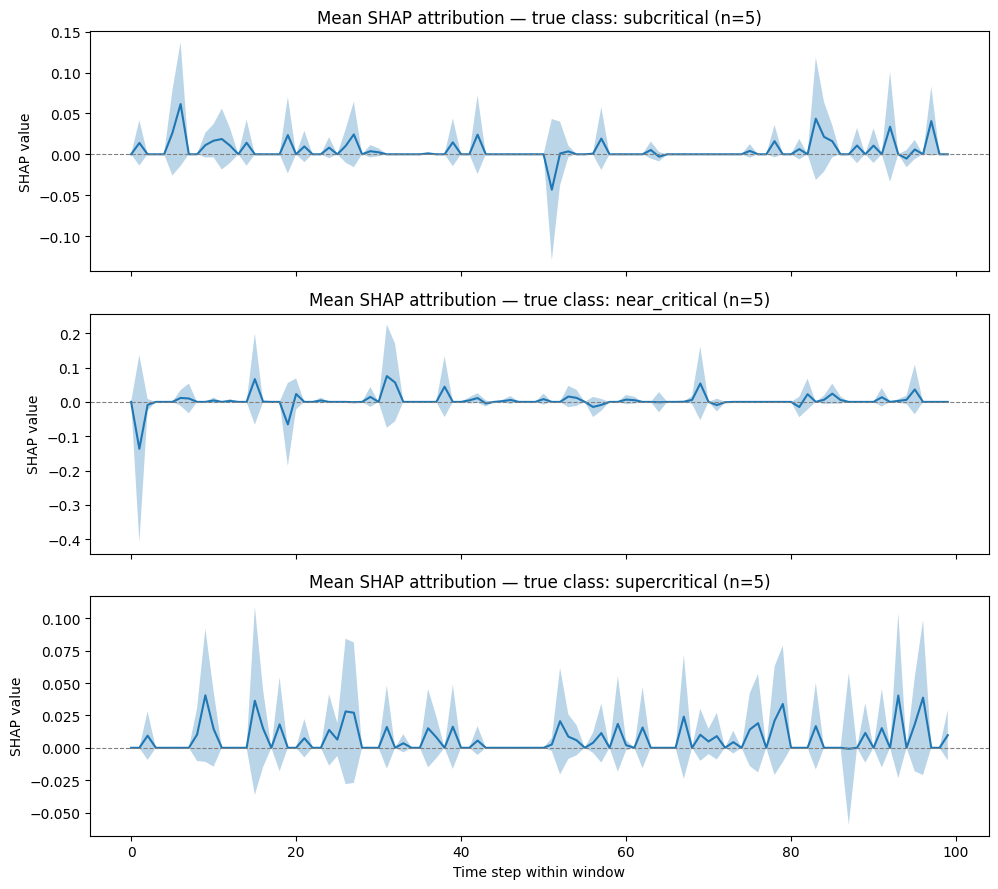

In [13]:
# Step 14b: Mean SHAP attribution per class

shap_arr = np.array(shap_values)  # shape (15, 100, 3)
print(f"shap_arr shape: {shap_arr.shape}")

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for class_idx in range(3):
    ax = axes[class_idx]

    mask = (sample_labels == class_idx)
    class_shap = shap_arr[mask, :, class_idx]  # (n_samples_in_class, window_size)

    mean_shap = class_shap.mean(axis=0)
    std_shap = class_shap.std(axis=0)

    time_steps = np.arange(class_shap.shape[1])
    ax.plot(time_steps, mean_shap, color='C0')
    ax.fill_between(time_steps, mean_shap - std_shap, mean_shap + std_shap, alpha=0.3)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f"Mean SHAP attribution — true class: {class_names[class_idx]} (n={mask.sum()})")
    ax.set_ylabel("SHAP value")

axes[-1].set_xlabel("Time step within window")
plt.tight_layout()
plt.savefig('shap_mean_attribution.png', dpi=100, bbox_inches='tight')
plt.show()

shap_arr shape after squeeze: (90, 100, 3)


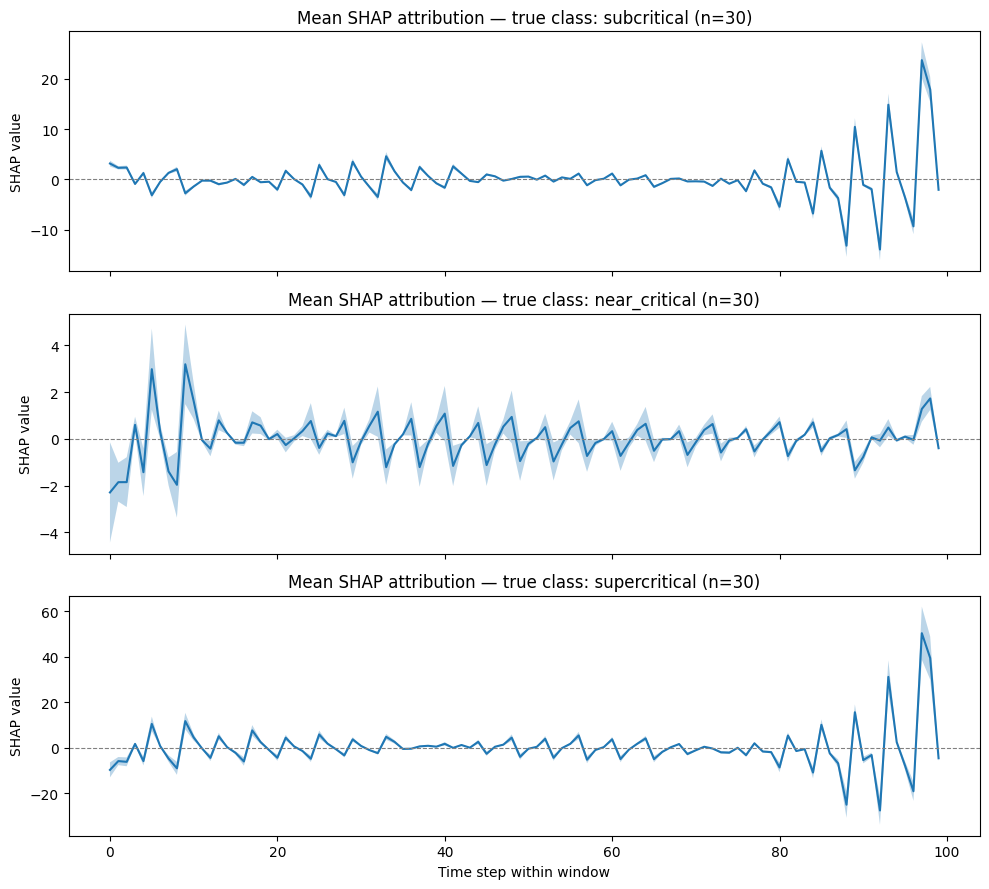

In [22]:
#REVISED
# Step 14b: Mean SHAP attribution per class

shap_arr = np.array(shap_values).squeeze(1)  # (90, 1, 100, 3) -> (90, 100, 3)
print(f"shap_arr shape after squeeze: {shap_arr.shape}")

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for class_idx in range(3):
    ax = axes[class_idx]

    mask = (sample_labels == class_idx)
    class_shap = shap_arr[mask, :, class_idx]  # (n_samples_in_class, window_size)

    mean_shap = class_shap.mean(axis=0)
    std_shap = class_shap.std(axis=0)

    time_steps = np.arange(class_shap.shape[1])
    ax.plot(time_steps, mean_shap, color='C0')
    ax.fill_between(time_steps, mean_shap - std_shap, mean_shap + std_shap, alpha=0.3)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f"Mean SHAP attribution — true class: {class_names[class_idx]} (n={mask.sum()})")
    ax.set_ylabel("SHAP value")

axes[-1].set_xlabel("Time step within window")
plt.tight_layout()
plt.savefig('shap_mean_attribution.png', dpi=100, bbox_inches='tight')
plt.show()

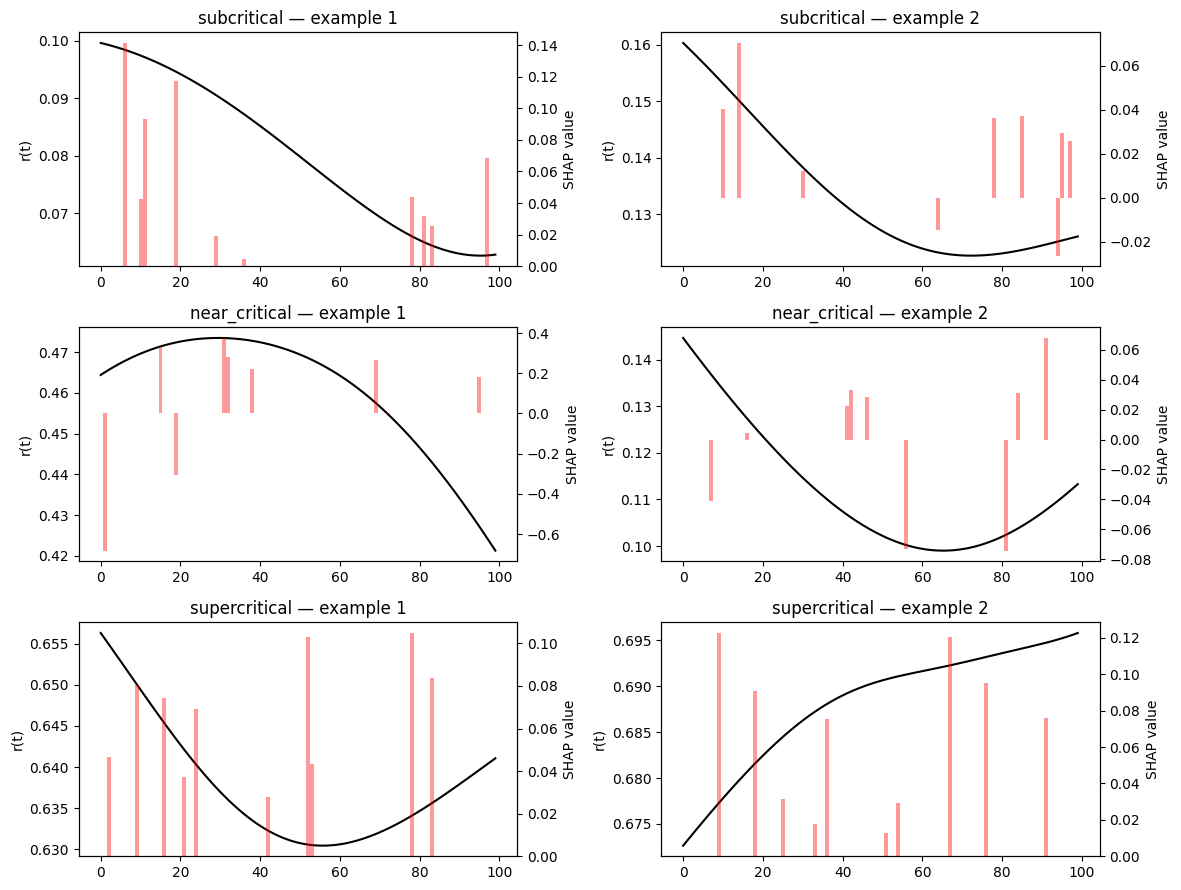

In [14]:
# Step 14c: Overlay SHAP importance on r(t) for individual examples

fig, axes = plt.subplots(3, 2, figsize=(12, 9))

for class_idx in range(3):
    mask = (sample_labels == class_idx)
    class_sample_idx = np.where(mask)[0][:2]

    for col, idx in enumerate(class_sample_idx):
        ax = axes[class_idx, col]

        r_window = X_explain[idx]
        shap_vals = shap_arr[idx, :, class_idx]

        ax2 = ax.twinx()
        ax.plot(r_window, color='black', linewidth=1.5, label='r(t)')
        ax2.bar(range(len(shap_vals)), shap_vals, alpha=0.4, color='red', width=1.0, label='SHAP')

        ax.set_title(f"{class_names[class_idx]} — example {col+1}")
        ax.set_ylabel("r(t)")
        ax2.set_ylabel("SHAP value")

plt.tight_layout()
plt.savefig('shap_individual_examples.png', dpi=100, bbox_inches='tight')
plt.show()

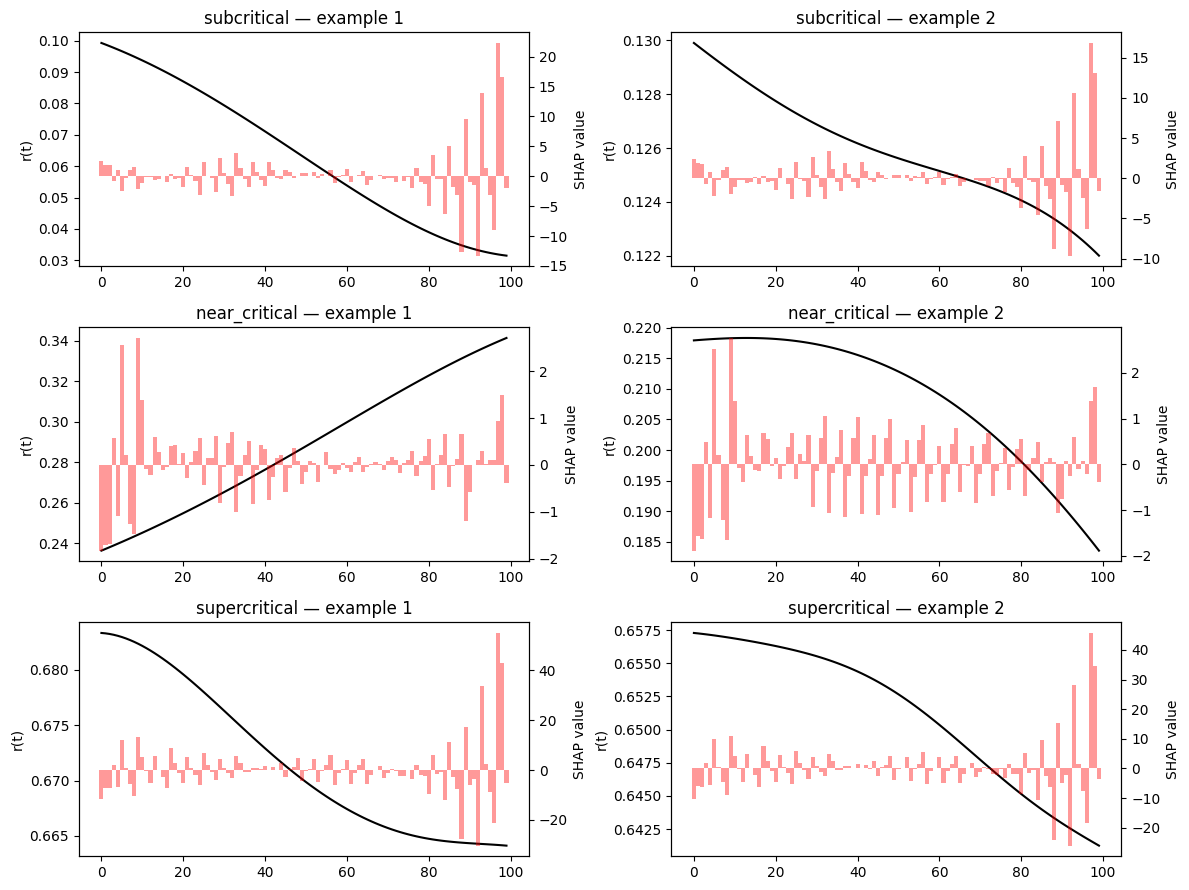

In [23]:
#REVISED
# Step 14c: Overlay SHAP importance on r(t) for individual examples

X_explain_np = X_explain.cpu().numpy().squeeze(1)  # (90, 1, 100) -> (90, 100)

fig, axes = plt.subplots(3, 2, figsize=(12, 9))

for class_idx in range(3):
    mask = (sample_labels == class_idx)
    class_sample_idx = np.where(mask)[0][:2]

    for col, idx in enumerate(class_sample_idx):
        ax = axes[class_idx, col]

        r_window = X_explain_np[idx]
        shap_vals = shap_arr[idx, :, class_idx]

        ax2 = ax.twinx()
        ax.plot(r_window, color='black', linewidth=1.5, label='r(t)')
        ax2.bar(range(len(shap_vals)), shap_vals, alpha=0.4, color='red', width=1.0, label='SHAP')

        ax.set_title(f"{class_names[class_idx]} — example {col+1}")
        ax.set_ylabel("r(t)")
        ax2.set_ylabel("SHAP value")

plt.tight_layout()
plt.savefig('shap_individual_examples.png', dpi=100, bbox_inches='tight')
plt.show()